<a href="https://colab.research.google.com/github/rigelyinwun/Prediction-of-Vegetation-Indices/blob/main/Machine%20Learning%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Source Code**

### GEE Integration

In [ ]:
import ee, geemap
import os
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import userdata

# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project=userdata.get('ProjectID'))

#### Map visualization

In [ ]:
Map = geemap.Map(center=[46.529, 6.746], zoom=2)

# Load MODIS dataset
dataset = ee.ImageCollection('MODIS/061/MOD13Q1') \
            .filter(ee.Filter.date('2018-01-01', '2018-05-01'))

# Select NDVI band
ndvi = dataset.select('NDVI')

# Define visualization parameters
ndviVis = {
    'min': 0,
    'max': 8000,
    'palette': [
        'ffffff', 'ce7e45', 'df923d', 'f1b555', 'fcd163', '99b718', '74a901',
        '66a000', '529400', '3e8601', '207401', '056201', '004c00', '023b01',
        '012e01', '011d01', '011301'
    ]
}

# Add NDVI layer to the map
Map.addLayer(ndvi.median(), ndviVis, 'NDVI')

# Display the map in Colab
Map

In [ ]:
Map2 = geemap.Map(center=[46.529, 6.746], zoom=6)

# Load MOD12Q1 dataset
dataset2 = ee.ImageCollection('MODIS/061/MCD12Q1')
igbpLandCover = dataset2.select('LC_Type1')

# Define visualization parameters
igbpLandCoverVis = {
    'min': 1.0,
    'max': 17.0,
    'palette': [
        '05450a', '086a10', '54a708', '78d203', '009900', 'c6b044', 'dcd159',
        'dade48', 'fbff13', 'b6ff05', '27ff87', 'c24f44', 'a5a5a5', 'ff6d4c',
        '69fff8', 'f9ffa4', '1c0dff'
    ]
}

# Reduce the ImageCollection to a single image (median)
landcover_image = igbpLandCover.median()

# Add layer to the map
Map2.addLayer(landcover_image, igbpLandCoverVis, 'IGBP Land Cover')

# Display map in Colab
Map2

#### Load data from Google Earth Engine

In [ ]:
# Define region of interest (ROI) -> malaysia
roi = ee.Geometry.Rectangle([99.6, 0.8, 119.3, 7.4])

# Load MODIS MOD13Q1 (NDVI/EVI) 16-day (from 2001 to 2025)
mod13 = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate("2001-01-01", "2025-12-31")
    .select(["NDVI", "EVI", "sur_refl_b01", "sur_refl_b02", "sur_refl_b03", "sur_refl_b07"])
)

# Convert to annual mean per year
def annual_mean(year):
    start = ee.Date.fromYMD(year,1,1)
    end = ee.Date.fromYMD(year,12,31)
    img = mod13.filterDate(start, end).mean()
    img = img.set('year', year)
    return img

years = list(range(2001, 2025))
annual_images = ee.ImageCollection([annual_mean(y) for y in years])

# Load MODIS MOD12Q1 (Land Cover) (from 2001 to 2025)
mod12 = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .select(["LC_Type1"])
    .filterDate("2001-01-01", "2025-12-31")
)

# Annual land cover (first image of the year)
def annual_lc(year):
    start = ee.Date.fromYMD(year,1,1)
    end = ee.Date.fromYMD(year,12,31)
    img = mod12.filterDate(start, end).first()
    img = img.set('year', year)
    return img

annual_lc_images = ee.ImageCollection([annual_lc(y) for y in years])

# merge 2 datasets
combined = []

for y in years:
    ndvi_img = annual_images.filter(ee.Filter.eq('year', y)).first()
    lc_img = annual_lc_images.filter(ee.Filter.eq('year', y)).first()
    img = ndvi_img.addBands(lc_img)
    combined.append(img)

combined_col = ee.ImageCollection(combined)

# export csv to drive
def sample_image(image):
    # Sample the image within the ROI
    sampled_features = image.sample(
        region=roi,
        scale=500,
        numPixels=5000,
        geometries=True
    )
    # Get the year property from the image and add it to each feature
    year = image.get('year')
    return sampled_features.map(lambda f: f.set('year', year))

# Map the sampling function over the ImageCollection
# and flatten the resulting FeatureCollection of FeatureCollections
sample = combined_col.map(sample_image).flatten()

task = ee.batch.Export.table.toDrive(
    collection=sample,
    description='MOD13_MCD12_Malaysia',
    fileFormat='CSV'
)

task.start()
print("Export started. Check your Google Drive soon.")


Export started. Check your Google Drive soon.


In [ ]:
print(task.status())

{'state': 'READY', 'description': 'MOD13_MOD12_Malaysia', 'priority': 100, 'creation_timestamp_ms': 1768957268441, 'update_timestamp_ms': 1768957268441, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'EW67QG2HQCYVVPMZVKR7HG3K', 'name': 'projects/upheld-conduit-459006-b2/operations/EW67QG2HQCYVVPMZVKR7HG3K'}


### Load dataset from CSV

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from scipy import stats

csv_file_path = '/content/MOD13_MCD12_Malaysia.csv'
df = pd.read_csv(csv_file_path)

df.head()

,system:index,EVI,LC_Type1,NDVI,sur_refl_b01,sur_refl_b02,sur_refl_b03,sur_refl_b07,year,.geo
0,0_1,5066.478261,2,7938.782609,384.695652,3194.913043,244.782609,623.913043,2001,"{""type"":""Point"",""coordinates"":[100.21574980221..."
1,0_4,4860.391304,2,7648.782609,503.086957,3260.652174,450.521739,597.739130,2001,"{""type"":""Point"",""coordinates"":[117.64568409548..."
2,0_8,4815.304348,2,7284.086957,596.086957,3334.260870,506.695652,648.739130,2001,"{""type"":""Point"",""coordinates"":[114.55135717989..."
3,0_16,4195.391304,14,6236.652174,739.260870,3064.000000,481.391304,833.826087,2001,"{""type"":""Point"",""coordinates"":[102.43291792862..."
4,0_18,6227.826087,2,8475.826087,336.304348,3891.217391,261.913043,636.565217,2001,"{""type"":""Point"",""coordinates"":[101.20163310053..."


In [ ]:
df.shape

(41546, 10)

In [ ]:
year_counts = df.groupby('year').size().reset_index(name='count')
year_counts

,year,count
0,2001,1748
1,2002,1827
2,2003,1823
3,2004,1824
4,2005,1824
5,2006,1822
6,2007,1799
7,2008,1822
8,2009,1826
9,2010,1826


### Part A: Data Preprocessing

#### Data Cleaning

In [ ]:
df.isna().sum()

,0
system:index,0
EVI,0
LC_Type1,0
NDVI,0
sur_refl_b01,0
sur_refl_b02,0
sur_refl_b03,0
sur_refl_b07,0
year,0
.geo,0


In [ ]:
df = df.dropna()

In [ ]:
df['EVI'] = df['EVI'] / 10000   # MODIS scaled integer -> actual EVI value
df['NDVI'] = df['NDVI'] / 10000  # MODIS scaled integer -> actual NDVI value

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Using IQR to handle outlier
Q1 = df[['NDVI', 'EVI']].quantile(0.25)
Q3 = df[['NDVI', 'EVI']].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df[['NDVI', 'EVI']] < lower_bound) | (df[['NDVI', 'EVI']] > upper_bound)).any(axis=1)
#df = df[~outlier_mask]  # Keep only non-outlier rows

print(f"DataFrame shape if IQR outlier removal: {df[~outlier_mask].shape}")
print(f"Number of rows with outliers: {outlier_mask.sum()}")

DataFrame shape if IQR outlier removal: (39021, 10)
Number of rows with outliers: 2525


*we choose to not remove the outliers because

*   Dropping them removes real extreme vegetation areas → incomplete map, missing parts of states.
*   Keeping them gives a higher R² and more realistic prediction.
*   For real-time vegetation mapping, extremes are part of reality — better to model them.

#### Data Transformation

In [ ]:
# Group MODIS Land Cover (17 classes) into simplified categories
def group_lc(lc):
    #Forest
    if lc in [1, 2, 3, 4,5]:
        return 'Forest'
    #Agriculture
    elif lc in [12, 14]:
        return 'Agriculture'
    elif lc == 13:
    #Urban
        return 'Urban'
    #Water, Snow, ice, Cropland / Natural Vegetation Mosaic
    else:
        return 'Other'

In [ ]:
df['LC_group'] = df['LC_Type1'].apply(group_lc)
display(df['LC_group'].value_counts())

,count
LC_group,
Forest,28391
Other,12592
Urban,561
Agriculture,2


Categorical Encoding

In [ ]:
# Create one-hot encoded columns for LC_group. This is for categorical features.
lc_encoded = pd.get_dummies(df['LC_group'], prefix='LC')
print(lc_encoded.head())

   LC_Agriculture  LC_Forest  LC_Other  LC_Urban
0           False       True     False     False
1           False       True     False     False
2           False       True     False     False
3           False      False      True     False
4           False       True     False     False


Feature Scaling

In [ ]:
# Using available numerical columns for scaling
features = df[['sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03', 'sur_refl_b07']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("First 5 rows of StandardScaler transformation:\n", features_scaled[:5])

First 5 rows of StandardScaler transformation:
 [[-0.99458252 -0.10321903 -1.27340271 -0.46710677]
 [-0.54760447  0.02686532 -0.38755563 -0.59204609]
 [-0.1964895   0.17252194 -0.14568868 -0.3486012 ]
 [ 0.34405356 -0.36226928 -0.25464113  0.53489828]
 [-1.1772805   1.27462548 -1.19964452 -0.40671251]]


In [ ]:
# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
lc_encoded_array = encoder.fit_transform(df[['LC_group']])

feature_names = encoder.get_feature_names_out(['LC_group'])
lc_encoded_df = pd.DataFrame(lc_encoded_array, columns=feature_names, index=df.index)

df = pd.concat([df, lc_encoded_df], axis=1)
print(df[['LC_group'] + list(feature_names)].head())

  LC_group  LC_group_Forest  LC_group_Other  LC_group_Urban
0   Forest              1.0             0.0             0.0
1   Forest              1.0             0.0             0.0
2   Forest              1.0             0.0             0.0
3    Other              0.0             1.0             0.0
4   Forest              1.0             0.0             0.0


Feature Engineering

In [ ]:
import json

# Extract longitude and latitude from the .geo column
def extract_coordinates(geo_json_str):
    try:
        geo_data = json.loads(geo_json_str)
        if geo_data['type'] == 'Point' and 'coordinates' in geo_data:
            return geo_data['coordinates'][0], geo_data['coordinates'][1]
    except (json.JSONDecodeError, KeyError):
        pass
    return None, None

df['longitude'], df['latitude'] = zip(*df['.geo'].apply(extract_coordinates))

# Drop rows where coordinate extraction failed
df = df.sort_values(['longitude','latitude','year'])

# Lag features: EVI from previous 1 and 2 years
df['EVI_lag1'] = df.groupby(['longitude','latitude'])['EVI'].shift(1)
df['EVI_lag2'] = df.groupby(['longitude','latitude'])['EVI'].shift(2)

# Drop rows with NaN after creating lag features
df = df.dropna(subset=['EVI_lag1','EVI_lag2'])

print(df[['longitude', 'latitude', 'year', 'EVI', 'EVI_lag1', 'EVI_lag2']].head(10))

       longitude  latitude  year       EVI  EVI_lag1  EVI_lag2
3654    99.62692  1.533833  2003  0.406609  0.382678  0.352413
5477    99.62692  1.533833  2004  0.399948  0.406609  0.382678
7302    99.62692  1.533833  2005  0.427657  0.399948  0.406609
9126    99.62692  1.533833  2006  0.433148  0.427657  0.399948
10952   99.62692  1.533833  2007  0.453857  0.433148  0.427657
12747   99.62692  1.533833  2008  0.425004  0.453857  0.433148
14569   99.62692  1.533833  2009  0.428743  0.425004  0.453857
16394   99.62692  1.533833  2010  0.491717  0.428743  0.425004
18220   99.62692  1.533833  2011  0.495826  0.491717  0.428743
20042   99.62692  1.533833  2012  0.493617  0.495826  0.491717


#### Data Reduction

Dimensionality Reduction using PCA

In [ ]:
# Select features
features = df[['sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03', 'sur_refl_b07']]

# Standardize the features
X_scaled = StandardScaler().fit_transform(features)

# Perform PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("\nPrincipal Component Loadings:\n")

# Get loadings (feature contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=[f'PC{i+1}' for i in range(3)]
)

print(loadings.round(3))

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {var:.3%}")

print("\nTop Features For Each Principle Component:")

for i, pc in enumerate(loadings.columns):
    print(f"\n{pc} (Variance: {explained_variance_ratio[i]:.2%}):")
    pc_loadings = loadings[pc].abs().sort_values(ascending=False)

    for feature in pc_loadings.index:
        value = loadings.loc[feature, pc]
        mark = "✓" if abs(value) > 0.5 else " "
        sign = "+" if value > 0 else "-"
        print(f"  {mark} {feature}: {sign}{abs(value):.3f}")

# Final PCA dataset
df_pca_3 = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(3)],
    index=df.index
)

print("\nFirst 5 PCA-transformed rows:")
print(df_pca_3.head().round(4))


Principal Component Loadings:

                PC1    PC2    PC3
sur_refl_b01  0.633 -0.077 -0.165
sur_refl_b02 -0.086  0.873 -0.476
sur_refl_b03  0.602 -0.157 -0.471
sur_refl_b07  0.479  0.455  0.724

Explained Variance Ratio:
PC1: 58.624%
PC2: 29.125%
PC3: 10.357%

Top Features For Each Principle Component:

PC1 (Variance: 58.62%):
  ✓ sur_refl_b01: +0.633
  ✓ sur_refl_b03: +0.602
    sur_refl_b07: +0.479
    sur_refl_b02: -0.086

PC2 (Variance: 29.13%):
  ✓ sur_refl_b02: +0.873
    sur_refl_b07: +0.455
    sur_refl_b03: -0.157
    sur_refl_b01: -0.077

PC3 (Variance: 10.36%):
  ✓ sur_refl_b07: +0.724
    sur_refl_b02: -0.476
    sur_refl_b03: -0.471
    sur_refl_b01: -0.165

First 5 PCA-transformed rows:
          PC1     PC2     PC3
3654   1.4675  0.8557  1.1945
5477   1.4212  0.6692  1.1382
7302   0.5163  0.5061  1.3403
9126   0.2981  0.5559  1.3944
10952 -0.3041  0.4258  1.2683


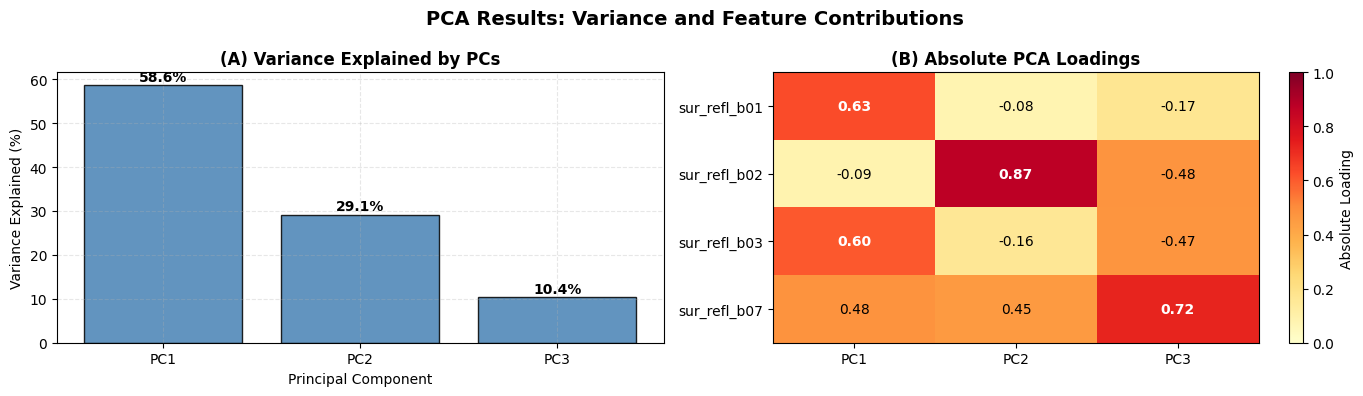

In [ ]:
# PCA
X_scaled = StandardScaler().fit_transform(df[['sur_refl_b01','sur_refl_b02','sur_refl_b03','sur_refl_b07']])
pca = PCA(n_components=3).fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ===== (A) VARIANCE PLOT =====
bars = ax1.bar(['PC1','PC2','PC3'], pca.explained_variance_ratio_*100,
               color='steelblue', edgecolor='black', alpha=0.85)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('(A) Variance Explained by PCs', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)

# Add labels
for bar, var in zip(bars, pca.explained_variance_ratio_):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{var:.1%}', ha='center', fontweight='bold')

# ===== (B) LOADINGS HEATMAP =====
loadings = pca.components_.T
im = ax2.imshow(np.abs(loadings), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax2.set_xticks(range(3))
ax2.set_xticklabels(['PC1','PC2','PC3'])
ax2.set_yticks(range(4))
ax2.set_yticklabels(['sur_refl_b01','sur_refl_b02','sur_refl_b03','sur_refl_b07'])
ax2.set_title('(B) Absolute PCA Loadings', fontweight='bold')

# Annotate loadings
for i in range(4):
    for j in range(3):
        val = loadings[i, j]
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                 color='white' if abs(val)>0.5 else 'black',
                 fontweight='bold' if abs(val)>0.5 else 'normal')

plt.colorbar(im, ax=ax2).set_label('Absolute Loading')
plt.suptitle('PCA Results: Variance and Feature Contributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Final Dataset (PCA + One-Hot LC)

In [ ]:
removed_cols = ['system:index', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03', 'sur_refl_b07', 'LC_Type1', 'LC_group', '.geo']
df = df.drop(columns=removed_cols)
df_final = pd.concat([df, df_pca_3], axis=1)
print(df_final.shape)
df_final.head()

(37330, 13)


,EVI,NDVI,year,LC_group_Forest,LC_group_Other,LC_group_Urban,longitude,latitude,EVI_lag1,EVI_lag2,PC1,PC2,PC3
3654,0.406609,0.613843,2003,0.0,1.0,0.0,99.62692,1.533833,0.382678,0.352413,1.467492,0.855682,1.194475
5477,0.399948,0.620987,2004,0.0,1.0,0.0,99.62692,1.533833,0.406609,0.382678,1.421175,0.669199,1.138212
7302,0.427657,0.659500,2005,0.0,1.0,0.0,99.62692,1.533833,0.399948,0.406609,0.516308,0.506054,1.340260
9126,0.433148,0.673152,2006,0.0,1.0,0.0,99.62692,1.533833,0.427657,0.399948,0.298060,0.555904,1.394362
10952,0.453857,0.698296,2007,0.0,1.0,0.0,99.62692,1.533833,0.433148,0.427657,-0.304057,0.425814,1.268340


### Part B: Model Training

In [ ]:
X = df_final.drop(columns=['EVI'])
y = df_final['EVI']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # need to follow time so no shuffle

In [ ]:
# Use Robust Scaler to reduce influence of outlier because outlier is meaningful
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

RobustScaler uses:
*   Median instead of mean
*   Interquartile Range (IQR) instead of standard deviation

This means:
*   Extreme values don’t dominate
*   Legitimate vegetation extremes remain
*   Models focus on typical vegetation behavior

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    # Cross-validation with multiple metrics
    # not using cross_val_score called twice for R2 and RMSE
    cv_results = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=3,
        scoring=['r2', 'neg_root_mean_squared_error'],
        n_jobs=-1,
        return_train_score=False
    )

    r2_scores = cv_results['test_r2']
    rmse_scores = -cv_results['test_neg_root_mean_squared_error']  # convert to positive

    # Store mean scores
    results.append({
        "Model": name,
        "RMSE_mean": rmse_scores.mean(),
        "R2_mean": r2_scores.mean()
    })

results_df = pd.DataFrame(results)
results_df

,Model,RMSE_mean,R2_mean
0,Linear Regression,0.014517,0.977828
1,Decision Tree,0.022235,0.948563
2,K-Nearest Neighbors,0.020783,0.956573
3,Random Forest,0.015801,0.974551
4,SVR,0.039231,0.848946
5,Gradient Boosting,0.015862,0.974941


Why RMSE and R²

RMSE (Root Mean Squared Error)

*   Measures average prediction error in the same unit as your target variable (EVI)
*   Sensitive to large errors → good if you want to penalize big mistakes


R² (Coefficient of Determination)

*   Measures how much of the variance in your target is explained by the model
*   Ranges from 0 to 1 (1 = perfect fit, 0 = model does no better than mean)

Example:
If actual EVI = 4000–5000 and predicted EVI = 3980–5020

RMSE tells you the average error magnitude (say 30–50)

R² tells you how well your model explains the variation in EVI

#### Hyperparameter Tuning

*   Linear Regression limited parameter to tune -> skip
*   Decision Tree -> proceed
*   KNN -> proceed
*   Random Forest -> proceed
*   SVR sensitive to large dataset, too slow to tune -> skip
*   Gradient Boosting -> proceed

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution
param_dist = {
    "n_estimators": [100, 150, 200],       # number of trees
    "max_depth": [None, 10, 15],           # depth of tree
    "min_samples_split": [2, 5, 10],       # min samples to split a node
    "min_samples_leaf": [1, 2, 4],         # min samples at leaf
    "max_features": ["sqrt", "log2"]       # features considered at each split
}

rf = RandomForestRegressor(random_state=42)

# Randomized Search
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=8,        # small iteration for speed
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit
random_search_rf.fit(X_train_scaled, y_train)

# Best estimator
best_rf = random_search_rf.best_estimator_

# Predict on test set
y_pred_rf = best_rf.predict(X_test_scaled)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Tuned RMSE:", rmse_rf)
print("Random Forest Tuned R2:", r2_rf)
print("Best Parameters:", random_search_rf.best_params_)

results.append({
    "Model": "Random Forest Tuned",
    "RMSE_mean": rmse_rf,
    "R2_mean": r2_rf
})

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest Tuned RMSE: 0.016701796523368968
Random Forest Tuned R2: 0.9733609239393555
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [ ]:
param_dist = {
    "n_estimators": [80, 100, 120],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.8, 1.0]
}

gbr = GradientBoostingRegressor(random_state=42)

random_search_gbr = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=8, # limited iteration to faster it
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_gbr.fit(X_train_scaled, y_train)

best_gbr = random_search_gbr.best_estimator_

y_pred_gbr = best_gbr.predict(X_test_scaled)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Tuned RMSE:", rmse_gbr)
print("Gradient Boosting Tuned R2:", r2_gbr)
print("Best Parameters:", random_search_gbr.best_params_)

results.append({
        "Model": "Gradient Boosting Tuned",
        "RMSE_mean": rmse_gbr,
        "R2_mean": r2_gbr
    })

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Gradient Boosting Tuned RMSE: 0.014205475422109034
Gradient Boosting Tuned R2: 0.9807289966380393
Best Parameters: {'subsample': 0.8, 'n_estimators': 80, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsRegressor()
grid_knn = GridSearchCV(knn, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Tuned RMSE:", rmse_knn)
print("KNN Tuned R2:", r2_knn)
print("Best Parameters:", grid_knn.best_params_)

results.append({
        "Model": "KNN Tuned",
        "RMSE_mean": rmse_knn,
        "R2_mean": r2_knn
    })

Fitting 3 folds for each of 16 candidates, totalling 48 fits
KNN Tuned RMSE: 0.019478728583275883
KNN Tuned R2: 0.9637661907748937
Best Parameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}


In [ ]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(dt, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_dt.fit(X_train_scaled, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test_scaled)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Tuned RMSE:", rmse_dt)
print("Decision Tree Tuned R2:", r2_dt)
print("Best Parameters:", grid_dt.best_params_)

results.append({
        "Model": "Decision Tree Tuned",
        "RMSE_mean": rmse_dt,
        "R2_mean": r2_dt
    })

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Decision Tree Tuned RMSE: 0.018087847238120586
Decision Tree Tuned R2: 0.9687560061220276
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
results_df = pd.DataFrame(results).sort_values(by="R2_mean", ascending=False)
results_df

,Model,RMSE_mean,R2_mean
7,Gradient Boosting Tuned,0.014205,0.980729
0,Linear Regression,0.014517,0.977828
5,Gradient Boosting,0.015862,0.974941
3,Random Forest,0.015801,0.974551
6,Random Forest Tuned,0.016702,0.973361
9,Decision Tree Tuned,0.018088,0.968756
8,KNN Tuned,0.019479,0.963766
2,K-Nearest Neighbors,0.020783,0.956573
1,Decision Tree,0.022235,0.948563
4,SVR,0.039231,0.848946


#### Data Visualization

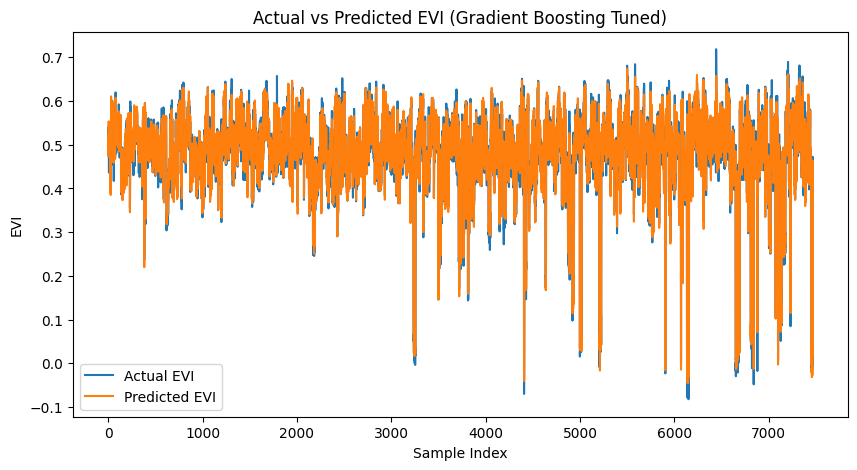

In [ ]:
# Line plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual EVI')
# use tuned gradient boost
plt.plot(y_pred_gbr, label='Predicted EVI')
plt.legend()
plt.title('Actual vs Predicted EVI (Gradient Boosting Tuned)')
plt.xlabel('Sample Index')
plt.ylabel('EVI')
plt.show()

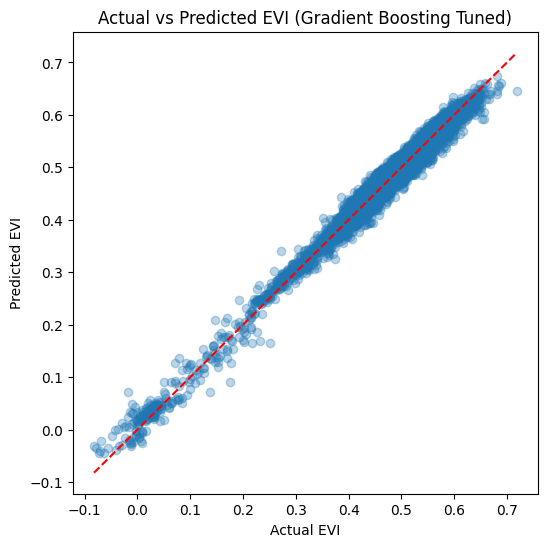

In [ ]:
# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel('Actual EVI')
plt.ylabel('Predicted EVI')
plt.title('Actual vs Predicted EVI (Gradient Boosting Tuned)')
plt.show()

### Model Application

Use tuned gradient boosting model to predict future year EVI

In [ ]:
def predict_future(model, scaler, last_data, feature_cols, years_forward=1):
    future_df = last_data.copy()
    future_predictions = []

    for step in range(years_forward):
        # Prepare features
        X_future = future_df[feature_cols]
        X_future_scaled = scaler.transform(X_future)

        # Predict EVI
        future_EVI = model.predict(X_future_scaled)

        # Store prediction along with year
        pred_row = future_df.copy()
        pred_row['EVI'] = future_EVI
        pred_row['year'] += 1  # move to next year
        future_predictions.append(pred_row)

        # Update lag features for next iteration
        future_df['EVI_lag2'] = future_df['EVI_lag1']
        future_df['EVI_lag1'] = future_df['EVI']
        future_df['EVI'] = future_EVI
        future_df['year'] += 1

    # Combine all predicted years into a single DataFrame
    return pd.concat(future_predictions, ignore_index=True)

In [ ]:
pixels_per_year = df_final.groupby('year').size().reset_index(name='count')
pixels_per_year

,year,count
0,2003,1742
1,2004,1822
2,2005,1821
3,2006,1819
4,2007,1749
5,2008,1742
6,2009,1824
7,2010,1826
8,2011,1824
9,2012,1767


In [ ]:
pixel_threshold = 1700  # adjust as needed
anchor_year = pixels_per_year[pixels_per_year['count'] > pixel_threshold]['year'].max()
print("Anchor year for prediction:", anchor_year)

Anchor year for prediction: 2022


In [ ]:
feature_cols = [
    "NDVI",
    "year",
    "LC_group_Forest",
    "LC_group_Other",
    "LC_group_Urban",
    "longitude",
    "latitude",
    "EVI_lag1",
    "EVI_lag2",
    "PC1",
    "PC2",
    "PC3",
]

target_start_year = 2025
target_end_year = 2029
years_forward = target_end_year - anchor_year  # how many steps to simulate

last_year_data = df_final[df_final['year'] == anchor_year].copy()

future_evi_df = predict_future(
    model=best_gbr,
    scaler=scaler,
    last_data=last_year_data,
    feature_cols=feature_cols,
    years_forward=years_forward
)

# Keep only target years
future_evi_df = future_evi_df[
    future_evi_df['year'].between(target_start_year, target_end_year)
]

future_evi_df

,EVI,NDVI,year,LC_group_Forest,LC_group_Other,LC_group_Urban,longitude,latitude,EVI_lag1,EVI_lag2,PC1,PC2,PC3
3644,0.494743,0.730948,2025,0.0,1.0,0.0,99.626920,1.533833,0.498359,0.492643,-0.341531,0.516048,0.375700
3645,0.427390,0.685343,2025,0.0,1.0,0.0,99.633518,7.248082,0.427390,0.409865,-0.610613,-1.380205,-0.750342
3646,0.356997,0.545030,2025,0.0,1.0,0.0,99.642104,3.057204,0.352948,0.364022,1.686750,-0.055790,0.239251
3647,0.507981,0.724635,2025,0.0,1.0,0.0,99.647307,1.298462,0.508575,0.499087,0.000499,0.957456,0.386474
3648,0.432973,0.617261,2025,0.0,1.0,0.0,99.687306,3.153350,0.435781,0.431452,2.030154,0.539888,-0.748274
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12749,0.397433,0.669470,2029,1.0,0.0,0.0,118.951474,5.155185,0.397433,0.397433,0.748654,-0.818603,-0.049697
12750,0.412312,0.736583,2029,1.0,0.0,0.0,118.986813,5.070338,0.412312,0.412312,-0.762212,-1.034990,0.979679
12751,0.491476,0.766335,2029,0.0,1.0,0.0,119.010880,5.391397,0.491476,0.493535,-1.568761,-0.971479,-0.535111
12752,0.431083,0.682770,2029,1.0,0.0,0.0,119.027761,5.128925,0.431083,0.431083,0.562027,-0.217263,0.235148


Mean EVI for 2025: 0.4645007629266328
Mean EVI for 2026: 0.46450568416738536
Mean EVI for 2027: 0.46444586841685037
Mean EVI for 2028: 0.46438294658493706
Mean EVI for 2029: 0.46442809901340804


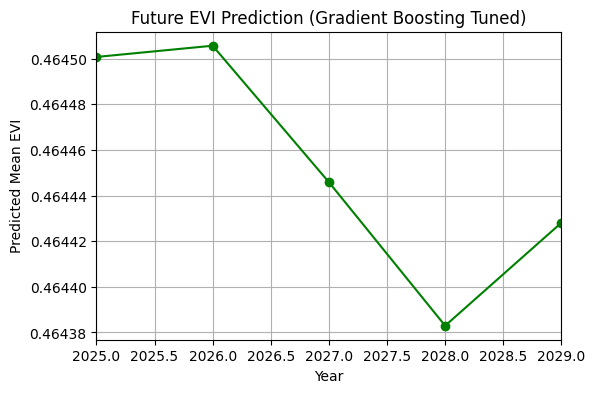

In [ ]:
# predicted 2025 till 2029 (5 years ahead)
future_years = [2025, 2026, 2027, 2028, 2029]

# Get mean EVI per year
future_mean_evi = []
for y in future_years:
    df_y = future_evi_df[future_evi_df['year'] == y]
    future_mean_evi.append(df_y['EVI'].mean())
    print(f"Mean EVI for {y}: {df_y['EVI'].mean()}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(future_years, future_mean_evi, marker='o', linestyle='-', color='green')
plt.xlabel("Year")
plt.ylabel("Predicted Mean EVI")
plt.title("Future EVI Prediction (Gradient Boosting Tuned)")
plt.xlim(2025, 2029)   # restrict x-axis to desired years
plt.grid(True)
plt.show()

Green Area Calculation

In [ ]:
# Threshold for greenish area (EVI > 0.4)
green_threshold = 0.4

# Calculate greenish area percentage
def calculate_green_area(df, threshold=green_threshold):
    green_area_count = (df['EVI'] > threshold).sum()
    total_area_count = df.shape[0]
    green_percentage = green_area_count / total_area_count * 100
    return green_area_count, green_percentage

In [ ]:
def green_area_by_year(df, year, threshold=0.4):
    df_year = df[df['year'] == year]
    return calculate_green_area(df_year, threshold)

green_2010 = green_area_by_year(df_final, 2010)
green_2024 = green_area_by_year(df_final, 2024)

print(f"2010 → Green pixels: {green_2010[0]}, Coverage: {green_2010[1]:.2f}%")
print(f"2024 → Green pixels: {green_2024[0]}, Coverage: {green_2024[1]:.2f}%")

2010 → Green pixels: 1471, Coverage: 80.56%
2024 → Green pixels: 1147, Coverage: 83.18%


In [ ]:
for yr in future_evi_df['year'].unique():
    df_year = future_evi_df[future_evi_df['year'] == yr]
    green_count, green_percent = calculate_green_area(df_year)
    print(f"Year {yr} -> Green pixels: {green_count}, Green coverage: {green_percent:.2f}%")

Year 2025 -> Green pixels: 1517, Green coverage: 83.26%
Year 2026 -> Green pixels: 1513, Green coverage: 83.04%
Year 2027 -> Green pixels: 1514, Green coverage: 83.10%
Year 2028 -> Green pixels: 1514, Green coverage: 83.10%
Year 2029 -> Green pixels: 1514, Green coverage: 83.10%


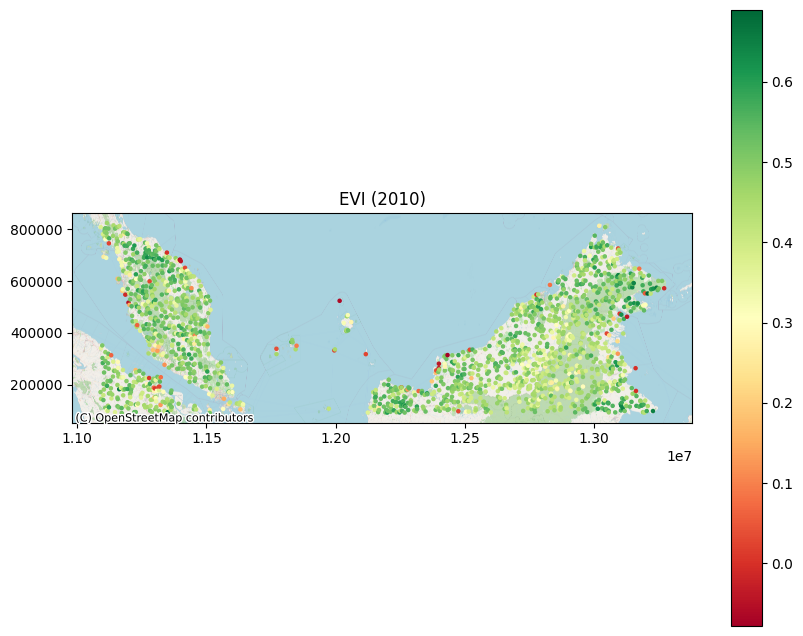

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

# Convert to GeoDataFrame
gdf = df_final.copy()
gdf['geometry'] = gdf.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs="EPSG:4326")

# reproject to Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Plot
yr = 2010
fig, ax = plt.subplots(figsize=(10,8))
gdf[gdf['year'] == yr].plot(
    column='EVI', cmap='RdYlGn', markersize=5, legend=True, ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
ax.set_title(f"EVI ({yr})")
plt.show()

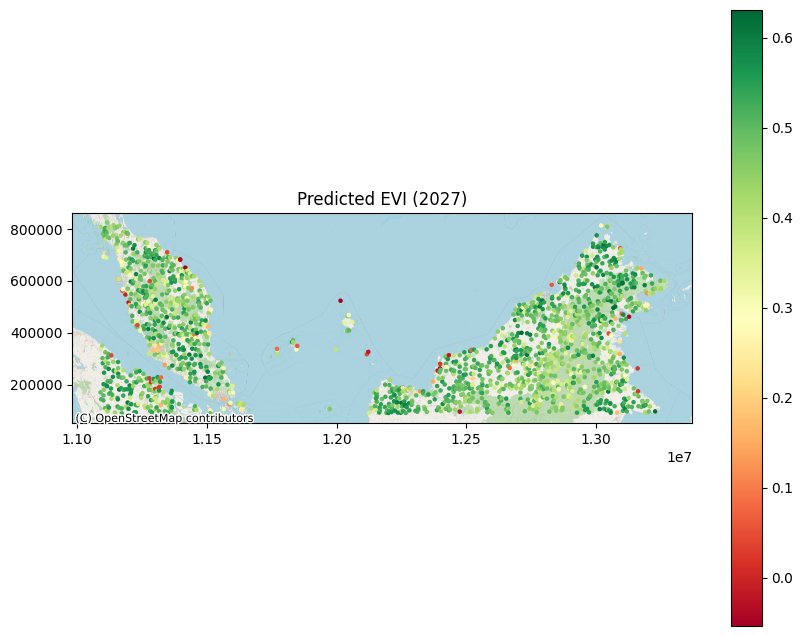

In [ ]:
# Convert to GeoDataFrame
future_pred_gdf = future_evi_df.copy()
future_pred_gdf['geometry'] = future_pred_gdf.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
future_pred_gdf = gpd.GeoDataFrame(future_pred_gdf, geometry='geometry', crs="EPSG:4326")

# reproject to Web Mercator
future_pred_gdf = future_pred_gdf.to_crs(epsg=3857)

# Plot
yr = 2027
fig, ax = plt.subplots(figsize=(10,8))
future_pred_gdf[future_pred_gdf['year'] == yr].plot(
    column='EVI', cmap='RdYlGn', markersize=5, legend=True, ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
ax.set_title(f"Predicted EVI ({yr})")
plt.show()